In [3]:
from pathlib import Path
warnings.filterwarnings("ignore", message=".*pyarrow version.*")
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from lightgbm import LGBMClassifier

# ---Notebook configuration---------------------------------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

# ---Project paths------------------------------------------------------------
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

DEV_DATA_PATH = PROCESSED_DATA_DIR / "dev_modeling_dataset.parquet"
FINAL_MODEL_PATH = MODELS_DIR / "final_lightgbm_pipeline.joblib"
FINAL_MODEL_METADATA_PATH = MODELS_DIR / "final_lightgbm_metadata.json"
FINAL_FEATURE_IMPORTANCE_PATH = MODELS_DIR / "final_lightgbm_feature_importance.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load Final Development Dataset

In [4]:
# ---Load modeling dataset----------------------------------------------------
dev_model_df = pd.read_parquet(DEV_DATA_PATH)

print("Development modeling dataset loaded successfully.")
print("Dataset shape:", dev_model_df.shape)
print()

# ---Define target and features-----------------------------------------------
target_col = "isFraud"

y_dev = dev_model_df[target_col].copy()
X_dev = dev_model_df.drop(columns=[target_col]).copy()

print("Feature matrix shape:", X_dev.shape)
print("Target vector shape:", y_dev.shape)
print()
print("Target distribution:")
print(y_dev.value_counts(normalize=True))
print()

Development modeling dataset loaded successfully.
Dataset shape: (472432, 464)

Feature matrix shape: (472432, 463)
Target vector shape: (472432,)

Target distribution:
isFraud
0   0.9649
1   0.0351
Name: proportion, dtype: float64



# Build Final Preprocessing Pipeline

In [5]:
# ---Detect feature types-----------------------------------------------------
numeric_features = X_dev.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_dev.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print()

# ---Numeric preprocessing----------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# ---Categorical preprocessing------------------------------------------------
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ---Column transformer-------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

Numeric features: 428
Categorical features: 35



# Define Final Tuned LightGBM Model

In [6]:
# ---Best parameters selected in notebook 06----------------------------------
best_lgbm_params = {
    "n_estimators": 500,
    "learning_rate": 0.07,
    "num_leaves": 127,
    "max_depth": -1,
    "min_child_samples": 100,
    "subsample": 0.70,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.50,
    "reg_lambda": 0.00,
}

# ---Define final classifier--------------------------------------------------
final_lgbm_classifier = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_lgbm_params,
)

# ---Assemble final modeling pipeline-----------------------------------------
final_lgbm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", final_lgbm_classifier),
    ]
)

# Train Final Model on Full Development Data

In [7]:
# ---Train final model--------------------------------------------------------
final_lgbm_model.fit(X_dev, y_dev)

print("Final LightGBM model training complete.")
print()

# ---Create model summary table-----------------------------------------------
final_model_summary = pd.DataFrame({
    "selected_model": ["LightGBM"],
    "training_dataset": ["Full development dataset"],
    "n_rows": [len(X_dev)],
    "n_features_before_preprocessing": [X_dev.shape[1]],
    "target_fraud_rate": [y_dev.mean()],
    "n_estimators": [best_lgbm_params["n_estimators"]],
    "learning_rate": [best_lgbm_params["learning_rate"]],
    "num_leaves": [best_lgbm_params["num_leaves"]],
    "max_depth": [best_lgbm_params["max_depth"]],
    "min_child_samples": [best_lgbm_params["min_child_samples"]],
    "subsample": [best_lgbm_params["subsample"]],
    "colsample_bytree": [best_lgbm_params["colsample_bytree"]],
    "reg_alpha": [best_lgbm_params["reg_alpha"]],
    "reg_lambda": [best_lgbm_params["reg_lambda"]],
})

final_model_summary

Final LightGBM model training complete.



,selected_model,training_dataset,n_rows,n_features_before_preprocessing,target_fraud_rate,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
0,LightGBM,Full development dataset,472432,463,0.0351,500,0.0700,127,-1,100,0.7000,0.8000,0.5000,0.0000


# Feature Importance

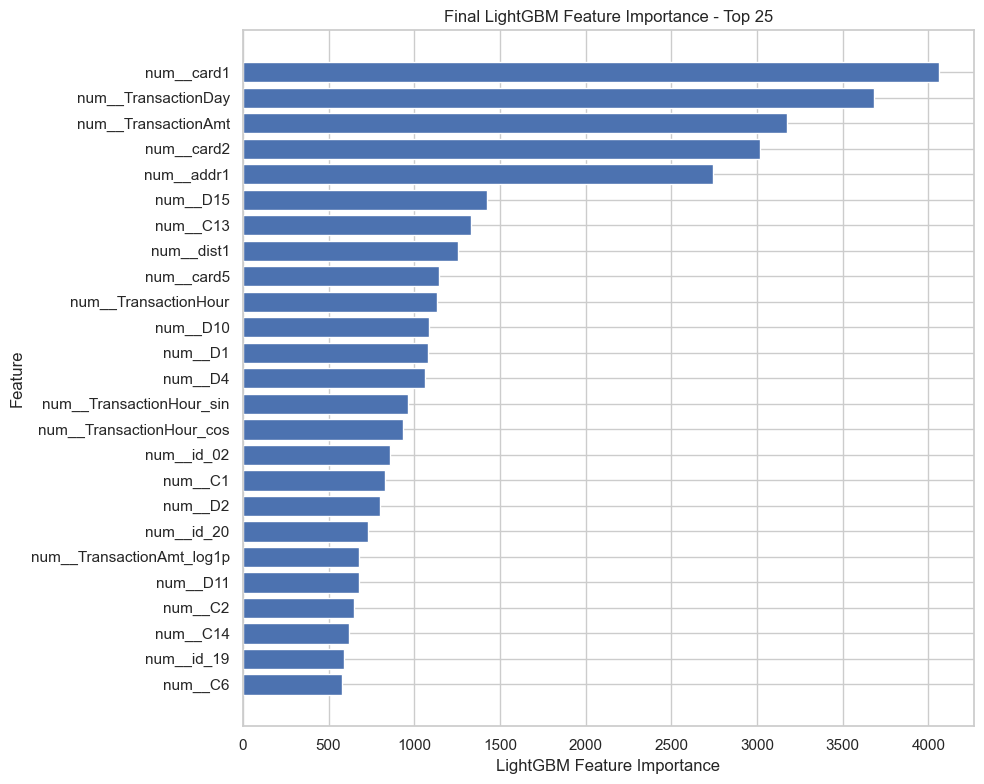

In [8]:
# ---Extract fitted components------------------------------------------------
fitted_preprocessor = final_lgbm_model.named_steps["preprocessing"]
fitted_classifier = final_lgbm_model.named_steps["classifier"]

# ---Recover transformed feature names----------------------------------------
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

# ---Build feature importance table-------------------------------------------
feature_importance_df = pd.DataFrame({
    "feature_name": transformed_feature_names,
    "importance": fitted_classifier.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(25)

# ---Plot top feature importances---------------------------------------------
top_n = 25
top_feature_importance = (
    feature_importance_df.head(top_n)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(
    y=top_feature_importance["feature_name"],
    width=top_feature_importance["importance"],
)
plt.title("Final LightGBM Feature Importance - Top 25")
plt.xlabel("LightGBM Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Risk Score Generation on Development Data

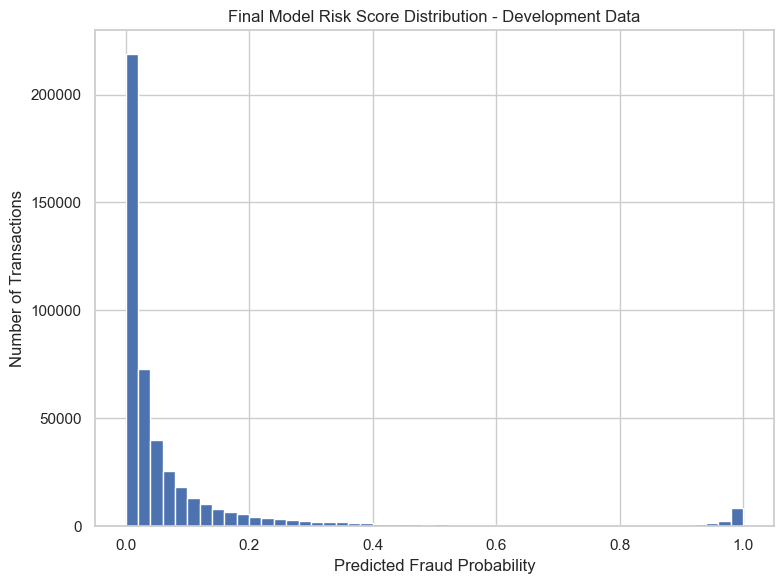

In [9]:
# ---Generate development risk scores-----------------------------------------
dev_pred_proba = final_lgbm_model.predict_proba(X_dev)[:, 1]

development_scored_df = pd.DataFrame({
    "actual_isFraud": y_dev.values,
    "fraud_score": dev_pred_proba,
})

# ---Risk score distribution summary------------------------------------------
risk_score_summary = development_scored_df["fraud_score"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
risk_score_summary

# ---Risk score distribution plot---------------------------------------------
plt.figure(figsize=(8, 6))
plt.hist(development_scored_df["fraud_score"], bins=50)
plt.title("Final Model Risk Score Distribution - Development Data")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Save Final Model Artifacts

In [10]:
# ---Save fitted pipeline-----------------------------------------------------
joblib.dump(final_lgbm_model, FINAL_MODEL_PATH)

# ---Save feature importance--------------------------------------------------
feature_importance_df.to_csv(FINAL_FEATURE_IMPORTANCE_PATH, index=False)

# ---Save model metadata------------------------------------------------------
final_model_metadata = {
    "model_name": "LightGBM",
    "project_stage": "07_final_model",
    "training_dataset": "dev_modeling_dataset.parquet",
    "target_column": target_col,
    "n_rows": int(len(X_dev)),
    "n_features_before_preprocessing": int(X_dev.shape[1]),
    "numeric_feature_count": int(len(numeric_features)),
    "categorical_feature_count": int(len(categorical_features)),
    "class_weight": "balanced",
    "best_params": best_lgbm_params,
    "artifacts": {
        "pipeline_path": str(FINAL_MODEL_PATH),
        "feature_importance_path": str(FINAL_FEATURE_IMPORTANCE_PATH),
    },
}

with open(FINAL_MODEL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(final_model_metadata, file, indent=4)

print("Final model saved to:", FINAL_MODEL_PATH.resolve())
print("Model metadata saved to:", FINAL_MODEL_METADATA_PATH.resolve())
print("Feature importance saved to:", FINAL_FEATURE_IMPORTANCE_PATH.resolve())
print()


Final model saved to: C:\Users\zeina\Models\final_lightgbm_pipeline.joblib
Model metadata saved to: C:\Users\zeina\Models\final_lightgbm_metadata.json
Feature importance saved to: C:\Users\zeina\Models\final_lightgbm_feature_importance.csv



# Final Outputs

In [11]:
# ---Display final artifacts summary------------------------------------------
final_artifacts_summary = pd.DataFrame({
    "artifact": [
        "Final fitted model pipeline",
        "Final model metadata",
        "Final feature importance table",
    ],
    "path": [
        str(FINAL_MODEL_PATH.resolve()),
        str(FINAL_MODEL_METADATA_PATH.resolve()),
        str(FINAL_FEATURE_IMPORTANCE_PATH.resolve()),
    ],
})

final_artifacts_summary

,artifact,path
0,Final fitted model pipeline,C:\Users\zeina\Models\final_lightgbm_pipeline....
1,Final model metadata,C:\Users\zeina\Models\final_lightgbm_metadata....
2,Final feature importance table,C:\Users\zeina\Models\final_lightgbm_feature_i...


## Conclusion

This notebook finalized the fraud detection model following the model comparison and hyperparameter tuning stages completed earlier in the project.

The most important outcomes of this stage are summarized below.

### 1. Final Model Selection
The tuned **LightGBM model** was selected as the final candidate model based on its strong validation performance during the tuning phase. LightGBM demonstrated the best balance between predictive power, scalability, and ability to capture nonlinear interactions across a large number of features.

The final model was trained using the **full development dataset (472,432 transactions)** to maximize the information available for learning fraud patterns before the final evaluation stage.

---

### 2. Robust Feature Utilization
The feature importance analysis shows that the model relies on a diverse set of signals rather than a single dominant feature. The most influential predictors include:

- Card identifiers (`card1`, `card2`, `card5`)
- Transaction characteristics (`TransactionAmt`)
- Temporal signals (`TransactionDay`, `TransactionHour`)
- Address information (`addr1`)
- Behavioral variables (`D*`, `C*`, `dist1`)
- Engineered transformations (`TransactionAmt_log1p`, cyclic hour features)

This distribution suggests that the model captures **multiple behavioral and transactional patterns associated with fraud**, which improves robustness and reduces the risk of over-reliance on isolated predictors.

---

### 3. Effective Fraud Risk Scoring
The predicted probability distribution shows a strongly skewed pattern where:

- the majority of transactions receive very low fraud probabilities
- a smaller subset receives significantly higher scores

This behavior is desirable for fraud detection systems because the model functions as a **risk scoring engine** rather than a simple binary classifier. The output probabilities allow downstream systems to prioritize transactions based on risk levels.

---

### 4. Operational Readiness
The final model artifacts were saved to support reproducibility and downstream deployment steps. These artifacts include:

- the trained preprocessing + model pipeline
- model configuration metadata
- global feature importance results

This ensures the model can be reliably reloaded and applied to future datasets without rebuilding the training pipeline.

---

### 5. Alignment with Fraud Detection Workflows
The model is designed to support operational decision workflows commonly used by payment processors, including:

- automatic approval of low-risk transactions
- manual review of medium-risk transactions
- automatic decline of high-risk transactions

The probability outputs generated by the model enable flexible threshold selection based on operational constraints such as investigation capacity and acceptable fraud loss levels.

---

### 6. Next Step: Holdout Evaluation
The next stage of the project will evaluate the finalized model on the **holdout dataset**, which contains transactions from a later time period that were not used during model development.

This step provides an unbiased estimate of how well the model generalizes to new transactions and confirms whether the observed performance improvements persist outside the development data.